In [8]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2               

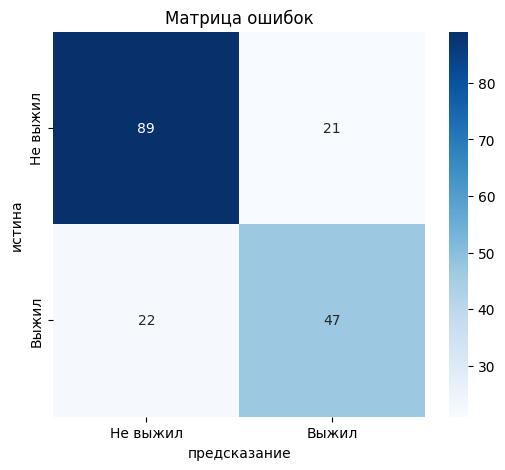

MSE: 0.1613
RMSE: 0.4016
MAE: 0.3231
R2: 0.3192


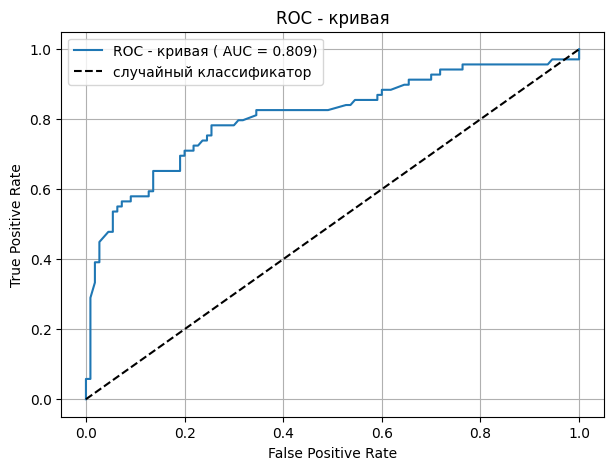

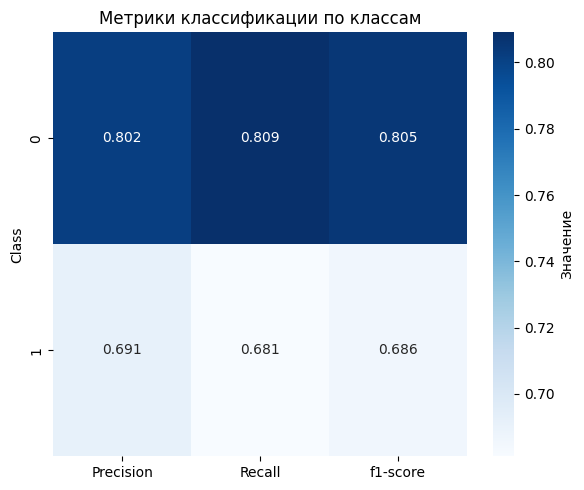

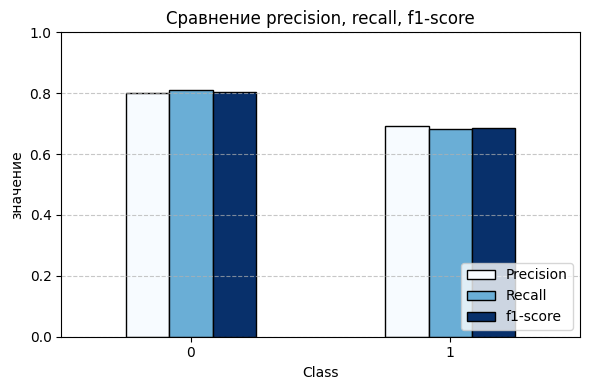

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Импорт классификатора — многослойного персептрона (искусственная нейронная сеть)
from sklearn.neural_network import MLPClassifier

# Импорт метрик качества для задач классификации и анализа вероятностей
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve, roc_auc_score
)

# Чтение исходного набора данных из CSV-файла
df = pd.read_csv('titanic.csv')

# Вывод типов данных каждого столбца для контроля
print(df.dtypes)
# Отображение структуры датафрейма (первые и последние строки)
print(df)

# Выделение подмножества признаков и целевой переменной
features = ['Pclass', 'Sex', 'Fare', 'Embarked']
target = "Survived"  # 1 — выжил, 0 — погиб

X = df[features]
y = df[target]

# Разделение данных на обучающую (80%) и тестовую (20%) выборки.
# stratify=y гарантирует сохранение исходного соотношения классов (выжил/погиб) в обеих выборках.
# random_state фиксирует генератор случайных чисел для воспроизводимости результатов.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Описание сквозного процесса обработки числовых признаков:
# Заполнение пропусков медианным значением по столбцу.
numeric_features = ["Fare"]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Описание сквозного процесса обработки категориальных признаков:
# 1) Заполнение пропусков самым частым значением.
# 2) Кодирование One-Hot. drop='first' удаляет первый столбец во избежание мультиколлинеарности.
# handle_unknown='ignore' защищает от падения, если в тесте появится неизвестная категория.
categorical_features = ['Pclass', 'Sex', 'Embarked']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Сборка единого трансформера колонок, раздельно обрабатывающего числовые и текстовые поля
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# СОЗДАНИЕ И ОБУЧЕНИЕ НЕЙРОСЕТИ (MLP)

# Сборка финального пайплайна: автоматическое применение предобработки перед передачей в модель
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(100, 50), # Архитектура сети: 2 скрытых слоя со 100 и 50 нейронами
        activation='relu',            # Функция активации ReLU для нелинейности внутри слоев
        solver='adam',                # Оптимизатор Adam для эффективного обновления весов
        max_iter=500,                 # Ограничение сверху по числу эпох обучения
        random_state=42,              # Фиксация случайных начальных весов сети
        early_stopping=True,          # Защита от переобучения: остановка, если ошибка на валидации растет
        validation_fraction=0.1,      # Выделение 10% обучающей выборки под внутреннюю валидацию
        n_iter_no_change=10           # Количество итераций без улучшений, после которых остановится обучение
    ))
])

# Запуск процесса обучения нейросети на тренировочном подмножестве
pipeline.fit(X_train, y_train)

# Предсказание жестких меток классов (0 или 1) для тестовых данных
y_pred = pipeline.predict(X_test)

# Расчет доли правильных ответов модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тесте {accuracy: .4f}")

print('\nОтчёт')
# Сохранение текстового отчета в виде словаря для последующего построения графиков
report = classification_report(y_test, y_pred, output_dict=True)
# Печать детального отчета (Precision, Recall, F1) с выводом 4 знаков после запятой
print(classification_report(y_test, y_pred, digits=4))

print("Матрица ошибок")
print(confusion_matrix(y_test, y_pred))


#График 1: Тепловая карта матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
# Построение матрицы со счетчиком истинных/ложных срабатываний (fmt='d' для целых чисел)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels = ['Не выжил', 'Выжил'],
           yticklabels = ['Не выжил', 'Выжил'])
plt.xlabel('предсказание')
plt.ylabel('истина')
plt.title('Матрица ошибок')
plt.show()

# Расчёт непрерывных оценок (для демонстрации вероятностей)
# Получение предсказанных моделью вероятностей принадлежности к положительному классу (индекс 1 - Выжил)
y_proba = pipeline.predict_proba(X_test)[:,1]

# Расчет метрик отклонения вероятностей от истинных бинарных меток классов
mse = mean_squared_error(y_test, y_proba)   # Среднеквадратичная ошибка
rmse = np.sqrt(mse)                        # Квадратный корень из MSE
mae = mean_absolute_error(y_test, y_proba)  # Средняя абсолютная ошибка
r2 = r2_score(y_test, y_proba)              # Коэффициент детерминации

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# График 2: ROC-кривая
# Вычисление координат True Positive Rate и False Positive Rate для разных порогов вероятности
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# Расчет площади под ROC-кривой (AUC). Чем ближе к 1.0, тем лучше разделяющая способность сети.
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC - кривая ( AUC = {auc:.3f})') 
plt.plot([0,1], [0,1], 'k--', label='случайный классификатор') # Пунктир случайной модели (AUC=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - кривая')
plt.legend()
plt.grid(True)
plt.show()

#Подготовка структуры данных для визуализации поклассовых метрик
metrics_df = pd.DataFrame({
    'Class': ['0', '1'],
    'Precision': [report['0']['precision'], report['1']['precision']],
    'Recall':[report['0']['recall'], report['1']['recall']],
    'f1-score':[report['0']['f1-score'], report['1']['f1-score']]
}).set_index('Class')

#График 3: Тепловая карта метрик классификации
plt.figure(figsize=(6, 5))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='Blues', cbar_kws={'label':'Значение'})
plt.title('Метрики классификации по классам')
plt.tight_layout()
plt.show()

# График 4: Столбчатая диаграмма сравнения метрик
metrics_df.plot(kind='bar', figsize=(6, 4), colormap='Blues', edgecolor='black')
plt.title('Сравнение precision, recall, f1-score')
plt.ylabel('значение')
plt.ylim(0, 1)                      # Ограничение оси Y от 0 до 1 для корректного восприятия долей
plt.xticks(rotation=0)              # Выравнивание подписей классов по горизонтали
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()


Precision(точность) 
измеряет - долю действительно выживших среди всех, кого модель назвала выжившими

Recall (Полнота)
Долю успешно найденных выживших среди абсолютно всех, кто на самом деле выжил
Например: на корабле в живых осталось 100 человек. Модель смогла правильно угадать и назвать выжившими 68 из них, а про остальные 32 человека ошибочно сказала, что они утонут. В этом случае рекол равен 0, 68 = 68%

F1-score (F-мера)
Это сбалансированное (гармоническое) среднее между точностью и полнотой. Она принимает высокие значения только тогда, когда и Precision, и Recall одинаково хорошиее. 

Модель можно легко обмануть. Например: если модель назовет выжившим вообще каждого пассажира на корабле, её Recall будет равен 100% (ведь она не пропустила ни одного выжившего). Но при этом её Precision будет ужасно низким, так как она запишет в выжившие сотни погибших.

f1-score защищает от таких крайностей. Если одна из метрик проваливается к нулю, f1-score тоже резко падает.

Распределение пассажиров по возрастным группам:
AgeGroup
Adult    891
Name: count, dtype: int64
--------------------------------------------------
Точность на тесте  0.7598

Отчёт
              precision    recall  f1-score   support

           0     0.8018    0.8091    0.8054       110
           1     0.6912    0.6812    0.6861        69

    accuracy                         0.7598       179
   macro avg     0.7465    0.7451    0.7458       179
weighted avg     0.7592    0.7598    0.7594       179

Матрица ошибок
[[89 21]
 [22 47]]


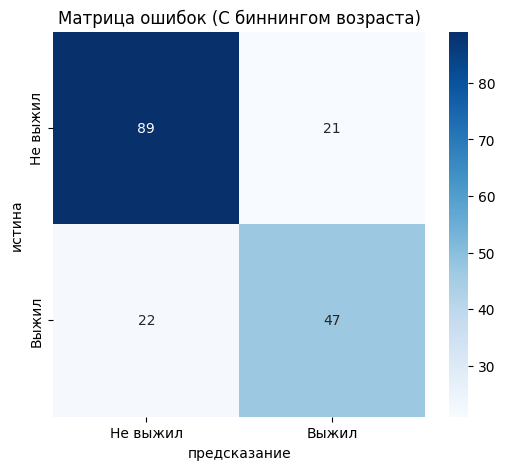

MSE: 0.1613
RMSE: 0.4016
MAE: 0.3231
R2: 0.3192


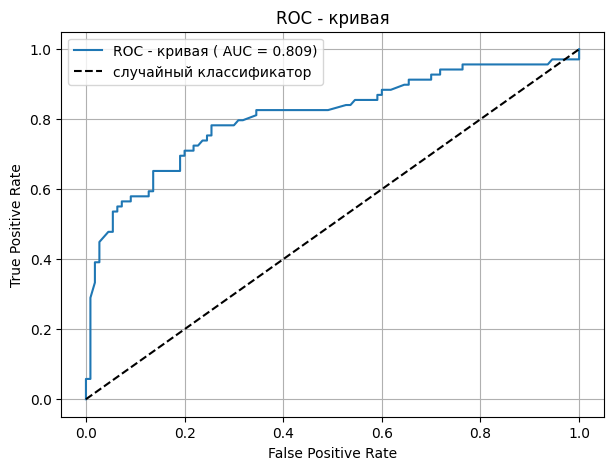

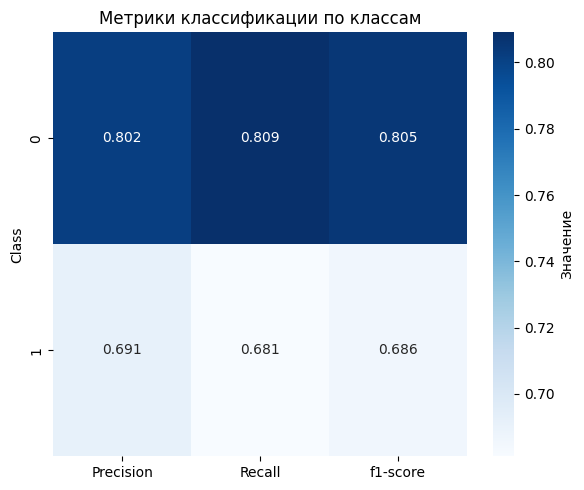

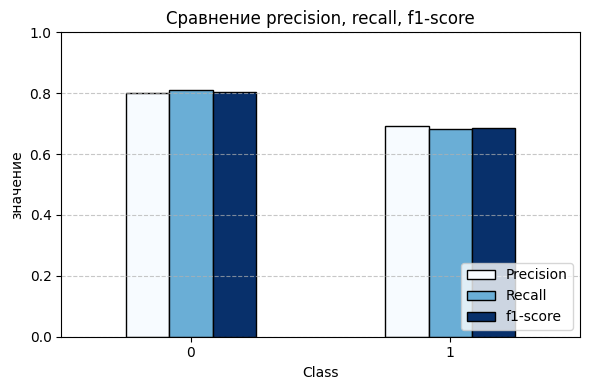

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score, roc_curve, roc_auc_score
)

# Загрузка данных
df = pd.read_csv('titanic.csv')

# Заполняем пустые значения возраста медианой перед разбивкой
df['Age'] = df['Age'].fillna(df['Age'].median())

# Отрезки для групп: [0-14], (14-60], (60-100]
bins = [0, 14, 60, 100]
labels = ['Child', 'Adult', 'Elderly']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels) [1]

print("Распределение пассажиров по возрастным группам:")
print(df['AgeGroup'].value_counts())
print("-" * 50)

# Определяем обновленный список признаков 
features = ['Pclass', 'Sex', 'Fare', 'Embarked', 'AgeGroup']
target = "Survived"

X = df[features]
y = df[target]

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Предобработка числовых признаков 
numeric_features = ["Fare"]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Предобработка категориальных признаков 
categorical_features = ['Pclass', 'Sex', 'Embarked', 'AgeGroup']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Объединение трансформеров
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Создание пайплайна
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    ))
])

# Обучение модели
pipeline.fit(X_train, y_train)

# Предсказание классов
y_pred = pipeline.predict(X_test)

# Вывод метрик классификации
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тесте {accuracy: .4f}")
print('\nОтчёт')
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred, digits=4))
print("Матрица ошибок")
print(confusion_matrix(y_test, y_pred))



#визуализация ошибок

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels = ['Не выжил', 'Выжил'],
           yticklabels = ['Не выжил', 'Выжил'])
plt.xlabel('предсказание')
plt.ylabel('истина')
plt.title('Матрица ошибок (С биннингом возраста)')
plt.show()


#расчёт метрик регрессии

y_proba = pipeline.predict_proba(X_test)[:,1]

mse = mean_squared_error(y_test, y_proba)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_proba)
r2 = r2_score(y_test, y_proba)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")


#построениее roc-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC - кривая ( AUC = {auc:.3f})') 
plt.plot([0,1], [0,1], 'k--', label='случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - кривая')
plt.legend()
plt.grid(True)
plt.show()


#датафрейм метрик 

metrics_df = pd.DataFrame({
    'Class': ['0', '1'],
    'Precision': [report['0']['precision'], report['1']['precision']],
    'Recall':[report['0']['recall'], report['1']['recall']],
    'f1-score':[report['0']['f1-score'], report['1']['f1-score']]
}).set_index('Class')

plt.figure(figsize=(6, 5))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='Blues', cbar_kws={'label':'Значение'})
plt.title('Метрики классификации по классам')
plt.tight_layout()
plt.show()

metrics_df.plot(kind='bar', figsize=(6, 4), colormap='Blues', edgecolor='black')
plt.title('Сравнение precision, recall, f1-score')
plt.ylabel('значение')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()
